In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

In [11]:
from ISLP import load_data

# Import auto dataset
auto = load_data("Auto")
auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

array([[<Axes: xlabel='mpg', ylabel='mpg'>,
        <Axes: xlabel='cylinders', ylabel='mpg'>,
        <Axes: xlabel='displacement', ylabel='mpg'>,
        <Axes: xlabel='horsepower', ylabel='mpg'>,
        <Axes: xlabel='weight', ylabel='mpg'>,
        <Axes: xlabel='acceleration', ylabel='mpg'>,
        <Axes: xlabel='year', ylabel='mpg'>,
        <Axes: xlabel='origin', ylabel='mpg'>],
       [<Axes: xlabel='mpg', ylabel='cylinders'>,
        <Axes: xlabel='cylinders', ylabel='cylinders'>,
        <Axes: xlabel='displacement', ylabel='cylinders'>,
        <Axes: xlabel='horsepower', ylabel='cylinders'>,
        <Axes: xlabel='weight', ylabel='cylinders'>,
        <Axes: xlabel='acceleration', ylabel='cylinders'>,
        <Axes: xlabel='year', ylabel='cylinders'>,
        <Axes: xlabel='origin', ylabel='cylinders'>],
       [<Axes: xlabel='mpg', ylabel='displacement'>,
        <Axes: xlabel='cylinders', ylabel='displacement'>,
        <Axes: xlabel='displacement', ylabel='displacement

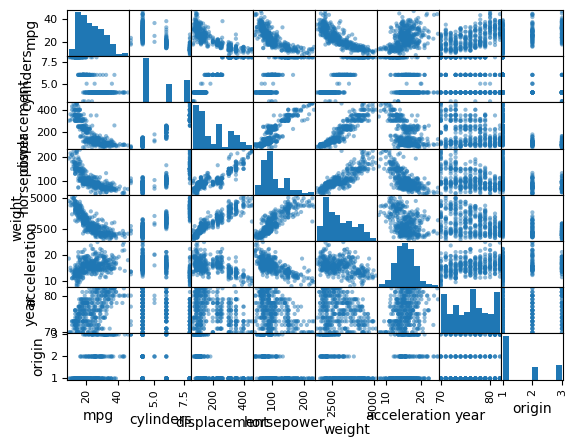

In [12]:
pd.plotting.scatter_matrix(auto)

In [13]:
auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [29]:
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS, summarize, poly)

cols = auto.drop(columns=["mpg"]).columns.tolist()
X = MS(cols).fit_transform(auto)
print(X)
y = auto["mpg"]


model = sm.OLS(y,X)
result = model.fit()
print(summarize(result))

                           intercept  cylinders  displacement  horsepower  \
name                                                                        
chevrolet chevelle malibu        1.0          8         307.0         130   
buick skylark 320                1.0          8         350.0         165   
plymouth satellite               1.0          8         318.0         150   
amc rebel sst                    1.0          8         304.0         150   
ford torino                      1.0          8         302.0         140   
...                              ...        ...           ...         ...   
ford mustang gl                  1.0          4         140.0          86   
vw pickup                        1.0          4          97.0          52   
dodge rampage                    1.0          4         135.0          84   
ford ranger                      1.0          4         120.0          79   
chevy s-10                       1.0          4         119.0          82   

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

X_null = X_null = pd.DataFrame({"const": 1}, index=y.index)
null_model = sm.OLS(y, X_null).fit()

anova_lm(null_model, result)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,391.0,23818.993469,0.0,NaN,NaN,NaN
1,384.0,4252.212530,7.0,19566.780939,252.428045,2.037106e-139


Since F = 252.42 is quite big and Pr(>F) = 2.03e-139 is very, very small we can confidently refuse H_0 and assume that at least one predictor is in relationship with the response

In [16]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        12:47:44   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

displacement, weight, year, origin seem to have a significant relationship to the response since their P>|t| is very small

The newer the model is, the higher the mpg is

Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

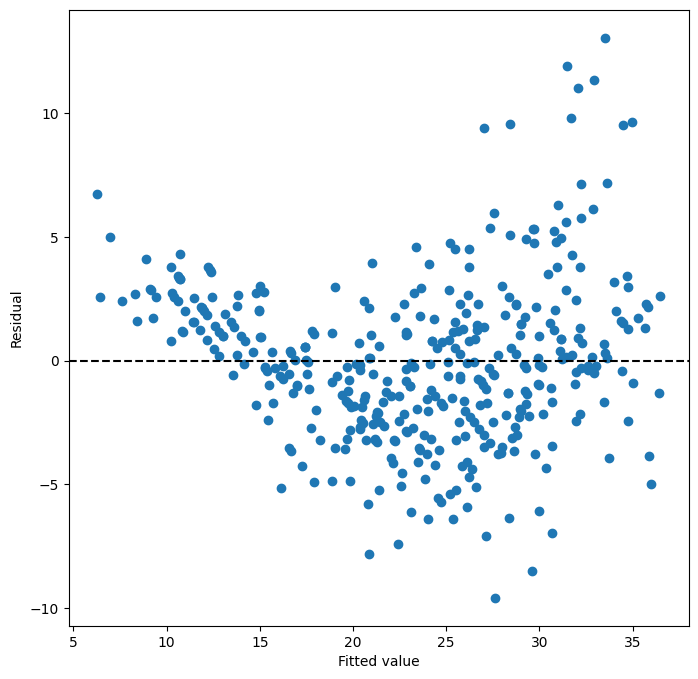

In [17]:
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(result.fittedvalues, result.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c="k", ls="--")

$$\mathbf{h_{ii} = \frac{1}{n} + \frac{(x_i - \bar{x})^2}{\sum_{j=1}^{n} (x_j - \bar{x})^2}}$$

13
-4.880153689236089


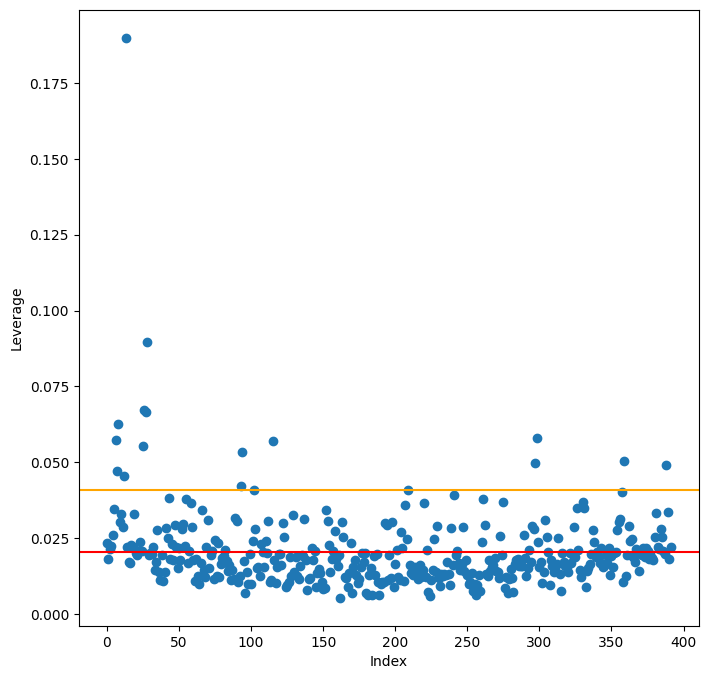

In [40]:
influence = result.get_influence()
max_leverage = np.argmax(influence.hat_matrix_diag)
print(max_leverage)
res_i = result.resid.iloc[max_leverage]
print(res_i)

ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), influence.hat_matrix_diag)

p = result.df_model
nobs = result.nobs
avg = (p + 1)/nobs
ax.axhline(avg, color="red")
ax.axhline(2*avg, color="orange")

ax.set_xlabel("Index")
ax.set_ylabel("Leverage")
plt.show()

There seems to be heteroskedasticity present. There are a couple of outliers (especially in the higher fitted value area at 10 and -10). The plot also suggest a higher-polynomial relationship between the target the variable and the predictors, based on the fact, that the residuals are not scattered more or less evenly (random) around the x axis (U-shape). Observation 13. has especially high leverage (but there are a couple which have relatively high leverage (above orange line))

Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?

In [ ]:
auto.describe()

interactions = [("cylinders", "horsepower"), ("horsepower", "weight"), ("acceleration", "weight"), ("origin", "weight")]
print(cols)

for interaction in interactions:
    X = MS(cols + [interaction]).fit_transform(auto)
    y = auto["mpg"]

    model = sm.OLS(y,X)
    result = model.fit()
    print(interaction)
    print(summarize(result)[f"{interaction[0]}:{interaction[1]}"])

['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
('cylinders', 'horsepower')


KeyError: -1